In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget classes:")
print(data.target_names)

print("\nClass distribution:")
print(pd.Series(y).value_counts())

X shape: (569, 30)
y shape: (569,)

Target classes:
['malignant' 'benign']

Class distribution:
1    357
0    212
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [5]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(
    X_train_scaled,
    y_train
)

y_pred = logistic_model.predict(X_test_scaled)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [6]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[41  1]
 [ 1 71]]


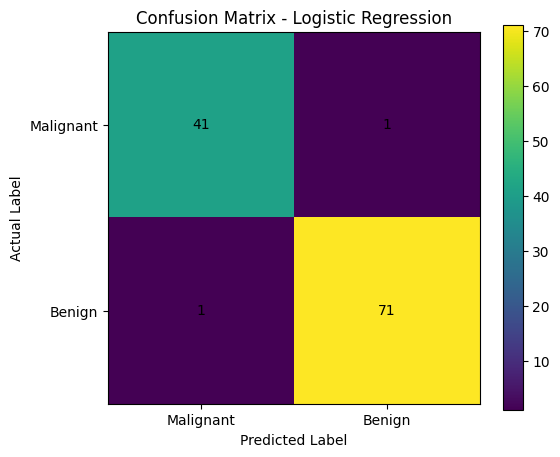

In [7]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.colorbar()

plt.xticks([0, 1], ["Malignant", "Benign"])
plt.yticks([0, 1], ["Malignant", "Benign"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [9]:
logistic_accuracy = accuracy_score(y_test, y_pred)
logistic_precision = precision_score(y_test, y_pred)
logistic_recall = recall_score(y_test, y_pred)
logistic_f1 = f1_score(y_test, y_pred)

print("Logistic Regression Results")
print("----------------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

Logistic Regression Results
----------------------------
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112


In [10]:
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc_score)

ROC-AUC: 0.9953703703703703


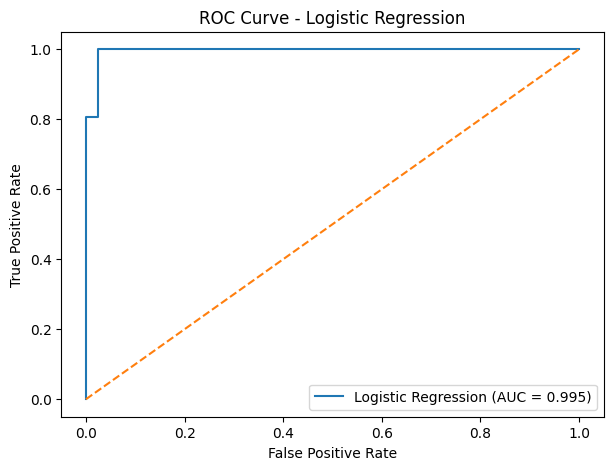

In [11]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

In [12]:
class_weight="balanced"

In [13]:
balanced_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

balanced_model.fit(
    X_train_scaled,
    y_train
)

y_pred_balanced = balanced_model.predict(X_test_scaled)

In [14]:
print("Balanced Logistic Regression")
print(classification_report(y_test, y_pred_balanced))

Balanced Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [15]:
balanced_accuracy = accuracy_score(y_test, y_pred_balanced)
balanced_precision = precision_score(y_test, y_pred_balanced)
balanced_recall = recall_score(y_test, y_pred_balanced)
balanced_f1 = f1_score(y_test, y_pred_balanced)

print("Accuracy :", balanced_accuracy)
print("Precision:", balanced_precision)
print("Recall   :", balanced_recall)
print("F1 Score :", balanced_f1)

Accuracy : 0.956140350877193
Precision: 0.9855072463768116
Recall   : 0.9444444444444444
F1 Score : 0.9645390070921985


In [16]:
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

y_pred_tree = tree_model.predict(X_test)

In [17]:
print("Decision Tree Classification Report")
print(classification_report(y_test, y_pred_tree))

Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [18]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        logistic_accuracy,
        balanced_accuracy,
        tree_accuracy
    ],
    "Precision": [
        logistic_precision,
        balanced_precision,
        tree_precision
    ],
    "Recall": [
        logistic_recall,
        balanced_recall,
        tree_recall
    ],
    "F1 Score": [
        logistic_f1,
        balanced_f1,
        tree_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Balanced Logistic Regression,0.956140,0.985507,0.944444,0.964539
2,Decision Tree,0.912281,0.955882,0.902778,0.928571


In [19]:
comparison.to_csv(
    "task4_model_comparison.csv",
    index=False
)

## Final Conclusion

In this task, a binary classification system was developed using the Breast Cancer dataset.

Logistic Regression was used as the baseline classification model. The model was evaluated using accuracy, precision, recall, F1-score, confusion matrix, ROC curve and ROC-AUC.

Class imbalance was also addressed using class weighting with Logistic Regression.

A Decision Tree Classifier was additionally trained to compare the performance and behavior of different classification approaches.

The final model selection was based not only on accuracy but also on precision, recall, F1-score and ROC-AUC. This is important because accuracy alone may not adequately represent classification performance, particularly when the costs of false positives and false negatives differ.

The comparison results are saved in `task4_model_comparison.csv`.